# I'll Cry in Another Walk-In
## Tracking Quit Rates in Accommodation and Food Services

**Series:** JTS720000000000000QUR - Quits Rate, Accommodation and Food Services (NAICS 72)  
**Period:** January 2016 - April 2026  
**Author:** Jason Staats  
**Updated:** June 2026

In [1]:
# --- Core ---
import requests
import json
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.stattools import acf

# --- Time Series ---
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

# --- Plot Styling ---
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'sans-serif'

API_KEY = "Your Key Here"
url = "https://api.bls.gov/publicAPI/v2/timeseries/data/"

payload = {
    "seriesid": ["JTS720000000000000QUR"],
    "startyear": "2016",
    "endyear": "2026",
    "registrationkey": API_KEY
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)

if response.status_code != 200:
    print(response.text)

else:
    data = response.json()

    records = []

    for item in data['Results']['series'][0]['data']:
        if item['period'].startswith('M'):
            records.append({
                "year": int(item['year']),
                "month": int(item['period'][1:]),
                "quit_rate": float(item['value'])
            })

df = pd.DataFrame(records).sort_values(['year', 'month'])
df.index.freq = 'MS'

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df = df.set_index('date')
df = df.drop(columns=['year', 'month'])
df

Status: 200


,quit_rate
date,
2016-01-01,4.3
2016-02-01,4.4
2016-03-01,4.4
2016-04-01,4.4
2016-05-01,4.5
...,...
2025-12-01,4.7
2026-01-01,4.7
2026-02-01,4.1


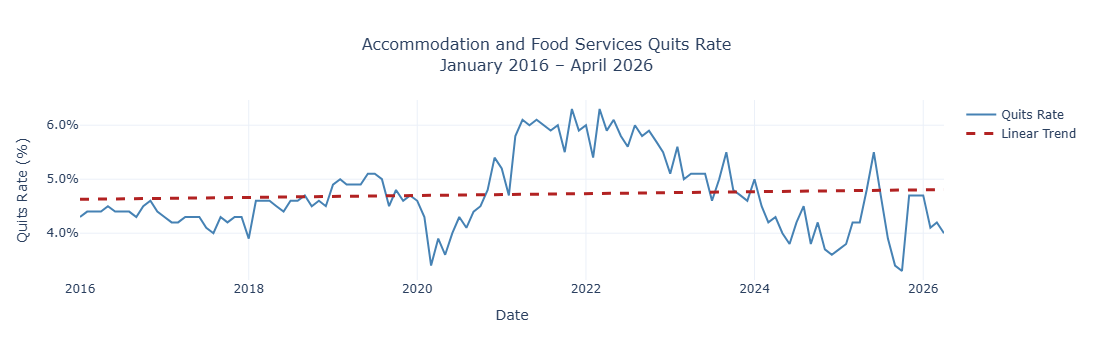

In [2]:
# =============================================================================
# Section 2: Full Series
# =============================================================================

# Create numeric index for regression
x_numeric = np.arange(len(df))

# Fit linear regression
slope, intercept = np.polyfit(x_numeric, df['quit_rate'], 1)

# Generate trend values
trend_line = slope * x_numeric + intercept

fig = go.Figure()

# Original series
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['quit_rate'],
    mode='lines',
    name='Quits Rate',
    line=dict(color='steelblue', width=2)
))

# Linear trend line
fig.add_trace(go.Scatter(
    x=df.index,
    y=trend_line,
    mode='lines',
    name='Linear Trend',
    line=dict(color='firebrick', width=3, dash='dash')
))

fig.update_layout(
    title=dict(
        text='Accommodation and Food Services Quits Rate<br>January 2016 – April 2026',
        x=0.5,
        font=dict(size=16)
    ),
    xaxis_title='Date',
    yaxis_title='Quits Rate (%)',
    yaxis=dict(
        ticksuffix='%',
        tickformat='.1f'
    ),
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

## Full Series

Much like Up or On the Rocks, it's worth clarifying what this series is actually measuring. The JOLTS
quits rate counts voluntary separations as a percentage of total employment in the
reference period. A worker who chooses to leave is a quit. Someone who gets laid off is
not. That distinction matters here because the quits rate is less a measure of how many
people are working and more a measure of how willing workers are to walk away from their
jobs.

Quit rates in accommodation and food services held relatively steady between 2016 and
early 2020, averaging around 4.5%. A sharp but brief decline followed in early 2020,
with rates recovering within a few months.

From mid-2021 through early 2022, quit rates climbed to a sustained peak of roughly 6%,
well above anything seen in the pre-pandemic period. Rates have trended back down since,
approaching pre-pandemic levels by late 2024, though with significant
month-to-month variability along the way.

The linear trend line reflects the overall upward drift across the full period. Despite
the swings, the series has ended up slightly higher than where it started, suggesting
some structural shift in worker behavior or bargaining power relative to 2016 norms.

*Note: JOLTS data is based on a survey of business establishments and is subject to
monthly revision as additional responses are received. The quits rate reflects
worker-initiated separations only and excludes layoffs, retirements, and other
employer-initiated exits.*

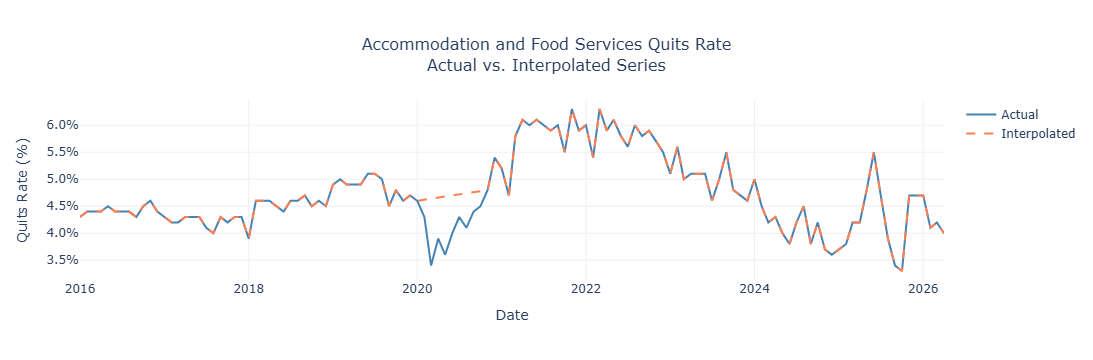

In [3]:
# =============================================================================
# COVID Interpolation
# =============================================================================

df_raw = df.copy()
df_interp = df.copy()
df_interp.loc['2020-02-01':'2020-10-01', 'quit_rate'] = np.nan
df_interp['quit_rate'] = df_interp['quit_rate'].interpolate(method='time')

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_raw.index, y=df_raw['quit_rate'],
    mode='lines', name='Actual',
    line=dict(color='steelblue', width=2),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in df_raw['quit_rate']]
))

fig.add_trace(go.Scatter(
    x=df_interp.index, y=df_interp['quit_rate'],
    mode='lines', name='Interpolated',
    line=dict(color='coral', width=2, dash='dash'),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in df_interp['quit_rate']]
))

fig.update_layout(
    title=dict(text='Accommodation and Food Services Quits Rate<br>Actual vs. Interpolated Series',
               x=0.5, font=dict(size=16)),
    xaxis_title='Date',
    yaxis_title='Quits Rate (%)',
    yaxis=dict(
        tickvals=[v / 10 for v in range(10, 75, 5)],
        ticktext=[f'{v / 10:.1f}%' for v in range(10, 75, 5)]
    ),
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

## COVID-19 Interpolation

Quit rates in early 2020 deviated sharply from the levels and patterns observed
throughout the rest of the series. Leaving those values in place would allow an
isolated period to distort the model's understanding of both trend and seasonal
structure.

To address this, quit rate values from February 2020 through October 2020 were replaced
using linear interpolation based on time. This bridges the gap between the pre-pandemic
level and the point where the series began returning to a more typical range, without
letting that period dominate the analysis.

The original series is shown alongside the adjusted version above for transparency, and
all subsequent analysis is based on the interpolated data.

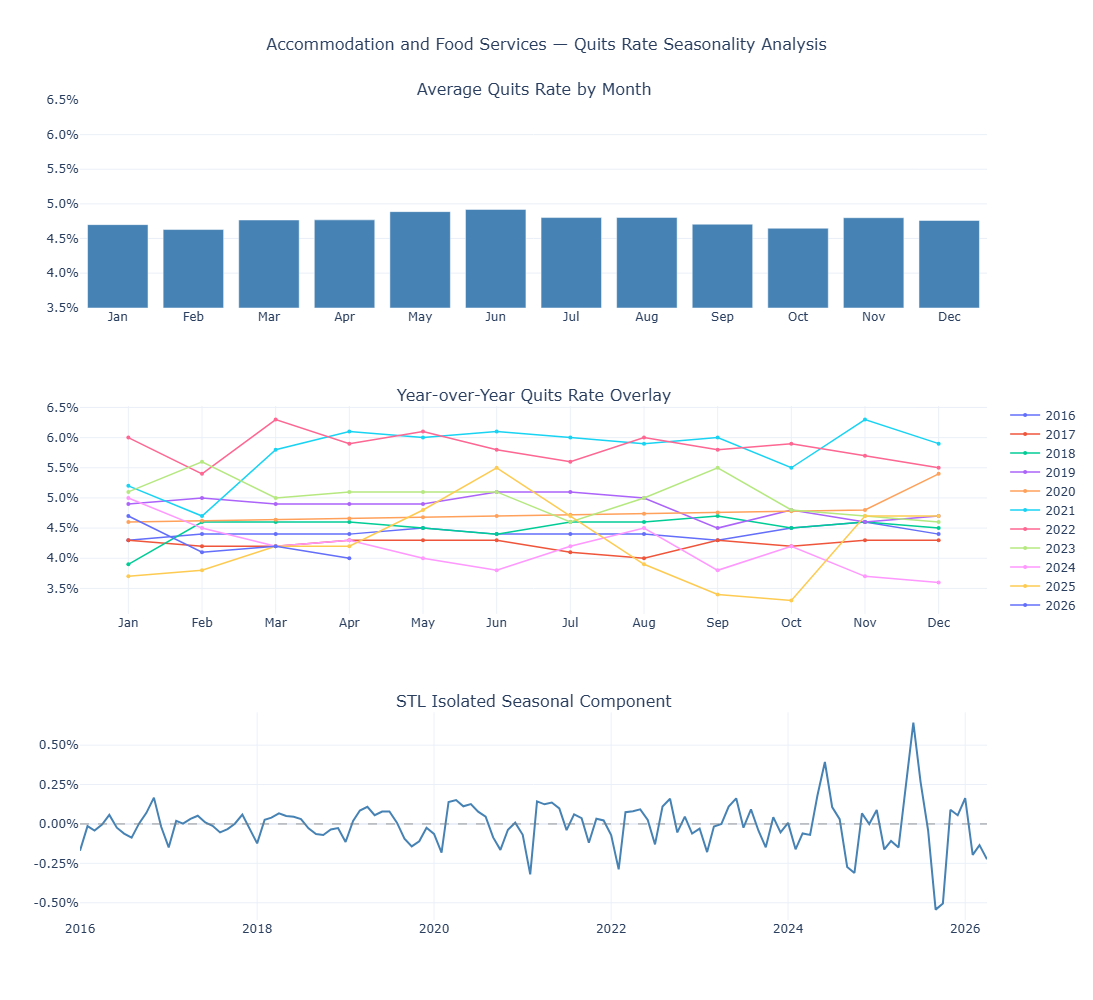

In [4]:
# =============================================================================
# Section 3: Seasonality Analysis
# =============================================================================
df_interp['month'] = df_interp.index.month
df_interp['year'] = df_interp.index.year
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

# STL fit
stl = STL(df_interp['quit_rate'], period=12)
stl_fit = stl.fit()
df_interp['seasonal'] = stl_fit.seasonal

monthly_avg = df_interp.groupby('month')['quit_rate'].mean().reset_index()

fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=('Average Quits Rate by Month',
                    'Year-over-Year Quits Rate Overlay',
                    'STL Isolated Seasonal Component'),
    vertical_spacing=0.12
)

# --- Plot 1: Monthly Average Bar ---
fig.add_trace(go.Bar(
    x=month_labels,
    y=monthly_avg['quit_rate'],
    marker_color='steelblue',
    name='Monthly Average',
    showlegend=False,
    hovertemplate='%{x}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in monthly_avg['quit_rate']]
), row=1, col=1)

fig.update_yaxes(
    range=[3.5, 6.5],
    tickvals=[3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5],
    ticktext=[f'{v:.1f}%' for v in [3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5]],
    row=1, col=1
)

# --- Plot 2: Year-over-Year Overlay ---
colors = px.colors.qualitative.Plotly
for i, (year, group) in enumerate(df_interp.groupby('year')):
    group = group.sort_values('month')
    fig.add_trace(go.Scatter(
        x=month_labels[:len(group)],
        y=group['quit_rate'],
        mode='lines+markers',
        name=str(year),
        line=dict(color=colors[i % len(colors)], width=1.5),
        marker=dict(size=4),
        hovertemplate=f'{year} %{{x}}: %{{customdata}}<extra></extra>',
        customdata=[f'{v:.2f}%' for v in group['quit_rate']]
    ), row=2, col=1)

fig.update_yaxes(
    tickvals=[3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5],
    ticktext=[f'{v:.1f}%' for v in [3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5]],
    row=2, col=1
)

# --- Plot 3: STL Seasonal Component ---
fig.add_trace(go.Scatter(
    x=df_interp.index,
    y=df_interp['seasonal'],
    mode='lines',
    name='Seasonal Component',
    showlegend=False,
    line=dict(color='steelblue', width=2),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.3f}%' for v in df_interp['seasonal']]
), row=3, col=1)

fig.add_hline(y=0, line_dash='dash', line_color='gray', line_width=0.8, row=3, col=1)

seasonal_ticks = [-0.50, -0.25, 0.00, 0.25, 0.50]
fig.update_yaxes(
    tickvals=seasonal_ticks,
    ticktext=[f'{v:.2f}%' for v in seasonal_ticks],
    row=3, col=1
)

fig.update_layout(
    title=dict(text='Accommodation and Food Services — Quits Rate Seasonality Analysis',
               x=0.5, font=dict(size=16)),
    height=1000,
    template='plotly_white',
    hovermode='closest',
    showlegend=True,
    legend=dict(
        x=1.02,
        y=0.50,
        xanchor='left',
        yanchor='middle'
    )
)

fig.show()

## Seasonality

Unlike employment in the sector, which follows a clear and consistent seasonal pattern
with strong summer peaks and winter lows, the quits rate doesn't show the same
structure. The monthly averages across the full period are relatively flat, with no
single month standing out as consistently higher or lower than the others.

The year-over-year overlay tells the more interesting story. Rather than a consistent
seasonal rhythm, what stands out is the level shift over time. Lines from 2021 and 2022
run noticeably higher than those from 2016 through 2019, with more recent years
returning toward the earlier range.

The STL seasonal component reinforces this. The values are small throughout, with swings
rarely exceeding 0.5 percentage points in either direction. There is some variation in
the pattern across years, but nothing that would suggest a strong or reliable seasonal
signal worth building into a forecast model.

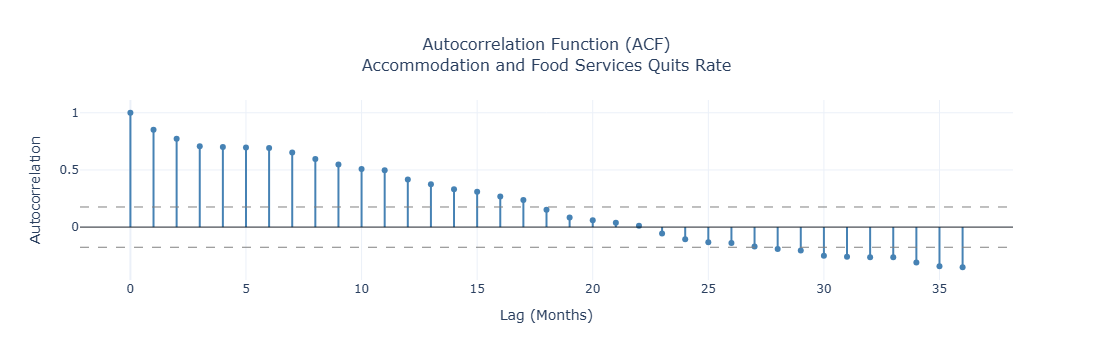

In [11]:
# =============================================================================
# Section 4: ACF
# =============================================================================
acf_values = acf(df_interp['quit_rate'], nlags=36)
lags = list(range(len(acf_values)))

fig = go.Figure()

# Zero line
fig.add_hline(y=0, line_color='black', line_width=0.8)

# 95% confidence interval bounds
n = len(df_interp['quit_rate'])
ci_bound = 1.96 / np.sqrt(n)
fig.add_hline(y=ci_bound, line_dash='dash', line_color='gray', line_width=1)
fig.add_hline(y=-ci_bound, line_dash='dash', line_color='gray', line_width=1)

# ACF stems
for i, (lag, val) in enumerate(zip(lags, acf_values)):
    fig.add_trace(go.Scatter(
        x=[lag, lag],
        y=[0, val],
        mode='lines',
        line=dict(color='steelblue', width=2),
        showlegend=False,
        hoverinfo='skip'
    ))

# ACF points
fig.add_trace(go.Scatter(
    x=lags,
    y=acf_values,
    mode='markers',
    marker=dict(color='steelblue', size=6),
    name='ACF',
    showlegend=False,
    hovertemplate='Lag %{x}: %{y:.3f}<extra></extra>'
))

fig.update_layout(
    title=dict(text='Autocorrelation Function (ACF)<br>Accommodation and Food Services Quits Rate',
               x=0.5, font=dict(size=16)),
    xaxis_title='Lag (Months)',
    yaxis_title='Autocorrelation',
    template='plotly_white',
    hovermode='closest'
)

fig.show()

## Autocorrelation

The autocorrelation function shows how similar the series is to itself at different time
lags, or how much current quit rates relate to past values.

The pattern here is a gradual, steady decline from lag 1 onward, with correlations
remaining positive for roughly the first 15 to 18 lags before crossing zero. That kind
of smooth decay is characteristic of an autoregressive process, where recent values
carry forward into the near future but the influence fades over time.

What is notably absent is the kind of discrete spike at lag 12 that would indicate
strong annual seasonality. In a series with clear seasonal structure, you would expect
to see a pronounced jump in correlation at the 12-month mark, reflecting the tendency
to repeat the same pattern year over year. The ACF here does not show that, which is
consistent with what the seasonality analysis found. The series has trend persistence
but not meaningful seasonality, and the model selection in the forecasting section
reflects that.

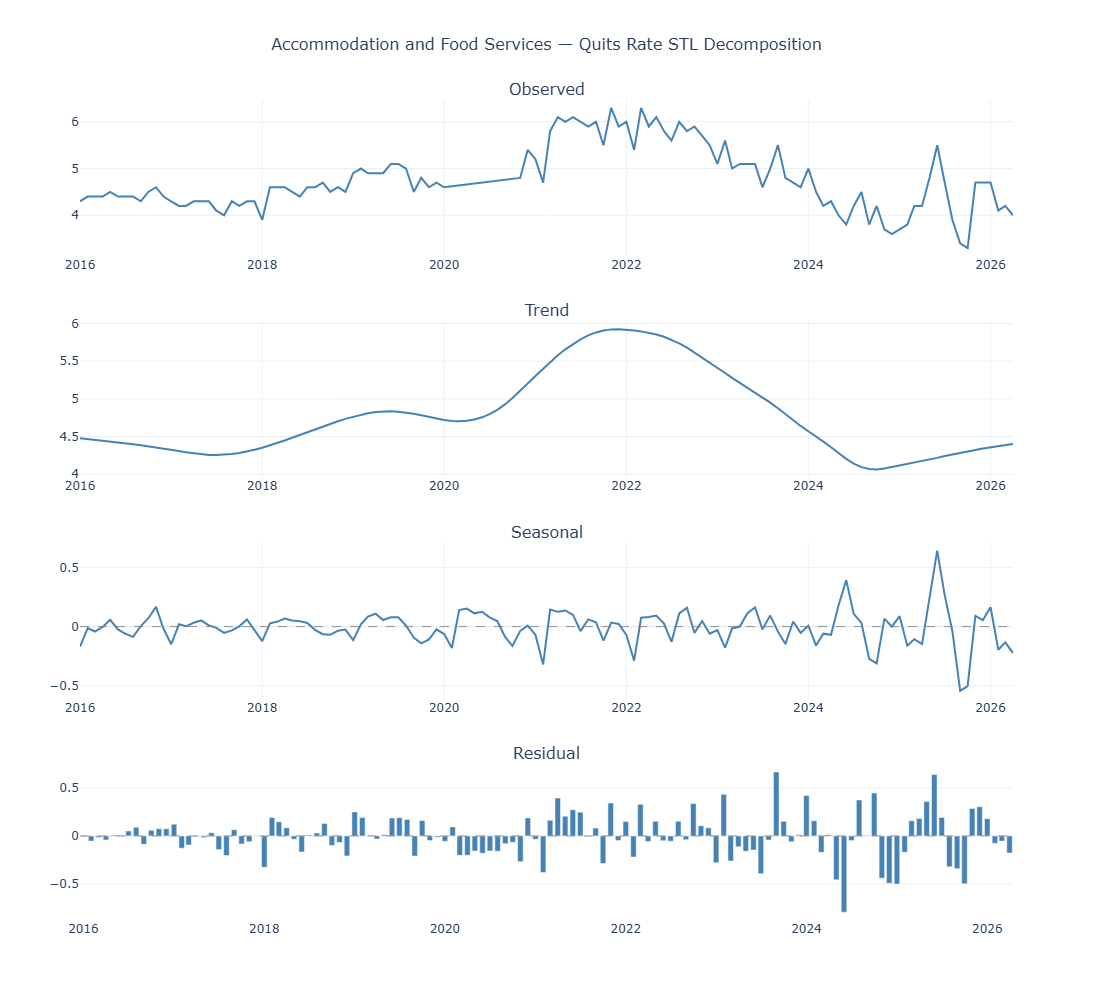

In [12]:
# =============================================================================
# Section 5: Full STL Decomposition
# =============================================================================
trend = stl_fit.trend
seasonal = stl_fit.seasonal
residual = stl_fit.resid

fig = make_subplots(
    rows=4, cols=1,
    subplot_titles=('Observed', 'Trend', 'Seasonal', 'Residual'),
    vertical_spacing=0.08
)

# --- Observed ---
fig.add_trace(go.Scatter(
    x=df_interp.index, y=df_interp['quit_rate'],
    mode='lines', name='Observed',
    line=dict(color='steelblue', width=2),
    showlegend=False,
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in df_interp['quit_rate']]
), row=1, col=1)

# --- Trend ---
fig.add_trace(go.Scatter(
    x=df_interp.index, y=trend,
    mode='lines', name='Trend',
    line=dict(color='steelblue', width=2),
    showlegend=False,
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in trend]
), row=2, col=1)

# --- Seasonal ---
fig.add_trace(go.Scatter(
    x=df_interp.index, y=seasonal,
    mode='lines', name='Seasonal',
    line=dict(color='steelblue', width=2),
    showlegend=False,
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.3f}%' for v in seasonal]
), row=3, col=1)

fig.add_hline(y=0, line_color='gray', line_width=0.8, line_dash='dash', row=3, col=1)

# --- Residual ---
fig.add_trace(go.Bar(
    x=df_interp.index, y=residual,
    name='Residual',
    marker_color='steelblue',
    showlegend=False,
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.3f}%' for v in residual]
), row=4, col=1)

fig.add_hline(y=0, line_color='gray', line_width=0.8, line_dash='dash', row=4, col=1)

fig.update_layout(
    title=dict(text='Accommodation and Food Services — Quits Rate STL Decomposition',
               x=0.5, font=dict(size=16)),
    height=1000,
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

## STL Decomposition

STL decomposition separates a time series into three components. The trend captures the
overall direction of the series across the full period. The seasonal component isolates
any repeating patterns tied to the calendar. The residual holds what neither trend nor
seasonality can explain.

The trend component captures the longer arc of the data. It shows relative stability
through the pre-pandemic period, a smooth transition through the interpolated window,
a clear climb to a peak around 2021 and 2022, and a gradual decline back toward earlier
levels from 2023 onward.

The seasonal component is notably muted. The values stay close to zero throughout the
full period, which reinforces the finding from the seasonality analysis that there is no
strong or consistent annual pattern in quit rates for this sector. The direction of the
seasonal effect also shifts across years, suggesting that whatever monthly variation
exists is not stable enough to be reliably modeled.

The residual component captures what is left after trend and seasonality are removed.
Most values stay close to zero, but there are periods where the deviations are more
pronounced, particularly around 2025, which saw unusual volatility in the raw series.

The observed panel reflects the interpolated series. The smooth transition through early
2020 is a result of the interpolation rather than actual recorded quit activity.

In [7]:
# =============================================================================
# Section 6: Forecasting
# =============================================================================

# --- Train/Validation Split ---
train = df_interp[df_interp.index < '2025-01-01']['quit_rate']
validation = df_interp[(df_interp.index >= '2025-01-01') & 
                (df_interp.index < '2026-01-01')]['quit_rate']

train.index = pd.DatetimeIndex(train.index, freq='MS')
validation.index = pd.DatetimeIndex(validation.index, freq='MS')

print(f"Training observations: {len(train)}")
print(f"Validation observations: {len(validation)}")

Training observations: 108
Validation observations: 12


In [8]:
# --- Model 1: ETS ---
# Seasonal removed -- series shows negligible seasonality
ets_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
).fit(optimized=True)
ets_forecast = ets_model.forecast(12)

# --- Model 2: ARIMA ---
# Dropping seasonal order -- ACF showed AR decay, not seasonal spikes
# (1,1,1) as starting point; revisit after checking PACF
arima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0)
).fit(disp=False)
arima_forecast = arima_model.forecast(12)

# --- Model 3: Naive (last value carried forward) ---
# Seasonal naive replaced with simple naive -- more appropriate
# for a non-seasonal series
naive_forecast = pd.Series(
    [train.iloc[-1]] * 12,
    index=validation.index
)

# --- Model 4: OLS with Trend and Seasonal Dummies ---
def build_ols_features(series):
    df_ols = pd.DataFrame({'quit_rate': series})
    df_ols['trend'] = range(len(df_ols))
    for m in range(1, 12):
        df_ols[f'month_{m}'] = (df_ols.index.month == m).astype(int)
    return df_ols

train_ols = build_ols_features(train)
X_train = train_ols.drop(columns='quit_rate')
y_train = train_ols['quit_rate']
ols_model = LinearRegression().fit(X_train, y_train)

future_ols = pd.DataFrame({'trend': range(len(train), len(train) + 12)},
                           index=validation.index)
for m in range(1, 12):
    future_ols[f'month_{m}'] = (future_ols.index.month == m).astype(int)
ols_forecast = pd.Series(ols_model.predict(future_ols), index=validation.index)

# --- MAE Comparison ---
models = {
    'ETS': ets_forecast,
    'ARIMA': arima_forecast,
    'Naive': naive_forecast,
    'OLS': ols_forecast
}

print("Model Validation MAE (January - December 2025):")
print("-" * 40)
for name, forecast in models.items():
    mae = mean_absolute_error(validation, forecast)
    print(f"{name:20s}: {mae:.3f} ppts")

Model Validation MAE (January - December 2025):
----------------------------------------
ETS                 : 1.037 ppts
ARIMA               : 0.647 ppts
Naive               : 0.725 ppts
OLS                 : 1.045 ppts


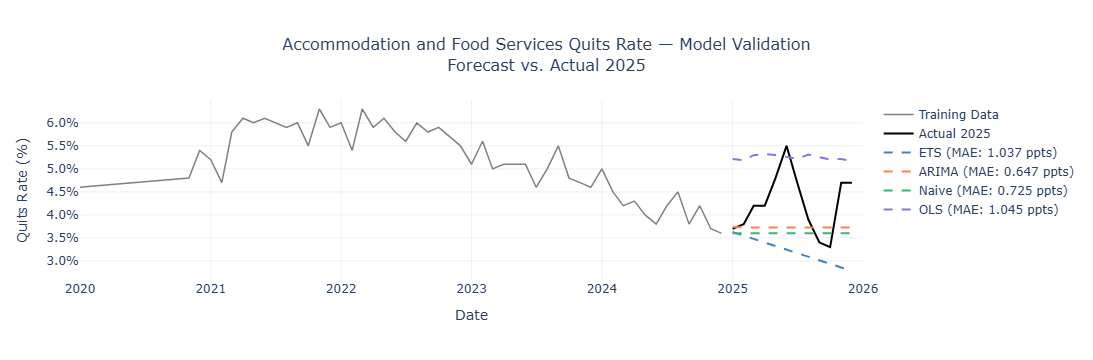

In [9]:
# --- Validation Plot ---
fig = go.Figure()

# Actual training data
fig.add_trace(go.Scatter(
    x=train.index, y=train.values,
    mode='lines', name='Training Data',
    line=dict(color='gray', width=1.5),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in train.values]
))

# Actual validation data
fig.add_trace(go.Scatter(
    x=validation.index, y=validation.values,
    mode='lines', name='Actual 2025',
    line=dict(color='black', width=2),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in validation.values]
))

# ETS forecast
fig.add_trace(go.Scatter(
    x=validation.index, y=ets_forecast.values,
    mode='lines', name=f'ETS (MAE: {mean_absolute_error(validation, ets_forecast):.3f} ppts)',
    line=dict(color='steelblue', width=2, dash='dash'),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in ets_forecast.values]
))

# ARIMA forecast
fig.add_trace(go.Scatter(
    x=validation.index, y=arima_forecast.values,
    mode='lines', name=f'ARIMA (MAE: {mean_absolute_error(validation, arima_forecast):.3f} ppts)',
    line=dict(color='coral', width=2, dash='dash'),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in arima_forecast.values]
))

# Naive forecast
fig.add_trace(go.Scatter(
    x=validation.index, y=naive_forecast.values,
    mode='lines', name=f'Naive (MAE: {mean_absolute_error(validation, naive_forecast):.3f} ppts)',
    line=dict(color='mediumseagreen', width=2, dash='dash'),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in naive_forecast.values]
))

# OLS forecast
fig.add_trace(go.Scatter(
    x=validation.index, y=ols_forecast.values,
    mode='lines', name=f'OLS (MAE: {mean_absolute_error(validation, ols_forecast):.3f} ppts)',
    line=dict(color='mediumpurple', width=2, dash='dash'),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in ols_forecast.values]
))

fig.update_layout(
    title=dict(text='Accommodation and Food Services Quits Rate — Model Validation<br>Forecast vs. Actual 2025',
               x=0.5, font=dict(size=16)),
    xaxis_title='Date',
    yaxis_title='Quits Rate (%)',
    yaxis=dict(
        tickvals=[v / 10 for v in range(20, 70, 5)],
        ticktext=[f'{v / 10:.1f}%' for v in range(20, 70, 5)]
    ),
    template='plotly_white',
    hovermode='x unified',
    xaxis=dict(range=['2020-01-01', '2026-01-01'])
)

fig.show()

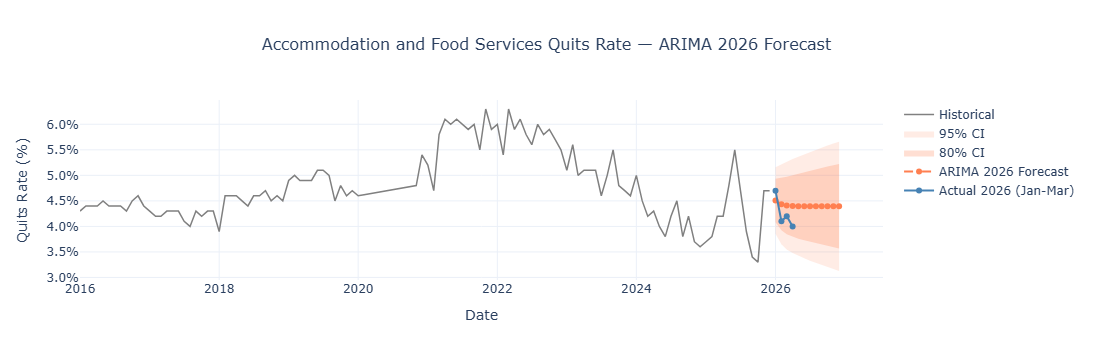

In [10]:
# --- Forward Forecast: 2026 ---
# Retrain ARIMA on full series through Dec 2025
full_series = df_interp[df_interp.index < '2026-01-01']['quit_rate']
full_series.index = pd.DatetimeIndex(full_series.index, freq='MS')

arima_final = SARIMAX(
    full_series,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0)
).fit(disp=False)

forecast_index = pd.date_range(start='2026-01-01', periods=12, freq='MS')

forecast_result = arima_final.get_forecast(12)
arima_2026 = forecast_result.predicted_mean
arima_2026.index = forecast_index

ci_80 = forecast_result.conf_int(alpha=0.20)
ci_95 = forecast_result.conf_int(alpha=0.05)
ci_80.index = forecast_index
ci_95.index = forecast_index

fig = go.Figure()

# Historical series
fig.add_trace(go.Scatter(
    x=full_series.index, y=full_series.values,
    mode='lines', name='Historical',
    line=dict(color='gray', width=1.5),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in full_series.values]
))

# 95% CI band
fig.add_trace(go.Scatter(
    x=pd.concat([ci_95.index.to_series(), ci_95.index.to_series()[::-1]]),
    y=pd.concat([ci_95.iloc[:, 1], ci_95.iloc[:, 0][::-1]]),
    fill='toself', fillcolor='rgba(255,127,80,0.15)',
    line=dict(width=0), showlegend=True, name='95% CI'
))

# 80% CI band
fig.add_trace(go.Scatter(
    x=pd.concat([ci_80.index.to_series(), ci_80.index.to_series()[::-1]]),
    y=pd.concat([ci_80.iloc[:, 1], ci_80.iloc[:, 0][::-1]]),
    fill='toself', fillcolor='rgba(255,127,80,0.25)',
    line=dict(width=0), showlegend=True, name='80% CI'
))

# 2026 forecast
fig.add_trace(go.Scatter(
    x=arima_2026.index, y=arima_2026.values,
    mode='lines+markers', name='ARIMA 2026 Forecast',
    line=dict(color='coral', width=2, dash='dash'),
    marker=dict(size=6),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in arima_2026.values]
))

# Actual Jan-Apr 2026 for immediate validation
actual_2026 = df_interp[df_interp.index >= '2026-01-01']['quit_rate']
fig.add_trace(go.Scatter(
    x=actual_2026.index, y=actual_2026.values,
    mode='lines+markers', name='Actual 2026 (Jan-Apr)',
    line=dict(color='steelblue', width=2),
    marker=dict(size=6),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in actual_2026.values]
))

fig.update_layout(
    title=dict(text='Accommodation and Food Services Quits Rate — ARIMA 2026 Forecast',
               x=0.5, font=dict(size=16)),
    xaxis_title='Date',
    yaxis_title='Quits Rate (%)',
    yaxis=dict(
        tickvals=[v / 10 for v in range(10, 75, 5)],
        ticktext=[f'{v / 10:.1f}%' for v in range(10, 75, 5)]
    ),
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

## Forecasting

To evaluate how well each model could predict unseen data, the most recent 12 months of
the series, January through December 2025, were held back as a validation set. Four
models were trained on January 2016 through December 2024 and asked to forecast the 12
months they had never seen. Their predictions were compared against actual 2025 values
using Mean Absolute Error, measured in percentage points.

| Model | MAE |
|---|---|
| ETS | 1.037 ppts |
| ARIMA | 0.647 ppts |
| Naive | 0.725 ppts |
| OLS | 1.045 ppts |

ARIMA produced the lowest average error at 0.647 percentage points per month. The Naive
model, which simply carries forward the last observed value, finished second and actually
outperformed ETS. That result is consistent with what the autocorrelation analysis
suggested: without strong seasonality or a clear trend direction at the end of the
training period, a simple persistence forecast is a tough benchmark to beat.

No model was positioned to anticipate the volatility that 2025 produced. Quit rates
spiked to 5.5% in June before falling back sharply later in the year, a swing that fell
well outside the range of anything in the training data. That outcome is an honest
finding rather than a modeling failure. The series ended 2024 at a relatively low and
stable level, and all models reasonably projected more of the same.

ARIMA was retrained on the full series through December 2025 and used to generate a
2026 forward forecast with 80% and 95% confidence intervals. The point forecast is
relatively flat, reflecting the same persistence behavior that made the model
competitive in validation. Actual quit rates from January through April 2026 have come
in within the 80% confidence interval, suggesting the model's uncertainty range is
reasonably calibrated even if the point estimate understates near-term variability. As
monthly JOLTS releases become available throughout 2026, the forecast will be evaluated
against realized outcomes.